In [2]:
datapath="final_dataset.csv"
nbook="/teamspace/uploads/m3 (1).ipynb"

In [3]:
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [4]:

import pandas as pd
import os
import numpy as np
import re
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm", disable=["ner"])  # NER is slow, not needed yet

In [5]:
cd

/teamspace/studios/this_studio


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/magics/osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/magics/osm.py:428: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
df = pd.read_csv(datapath)

print(df.shape)
print(df.head())
print(df['label'].value_counts())  # check label balance
print(df.isnull().sum())               # check for nulls

(471874, 3)
                                                text  label        source_type
0  Venus, sometimes called the "Evening star" it ...    0.0              essay
1  In our generations we have many ways of transp...    0.0              essay
2  her new employer. Through a series of coincide...    0.0  booksummaries.txt
3  I am a student in grade 8, and I strongly beli...    1.0              essay
4  University education is a highly debated topic...    1.0              essay
label
0.0    250000
1.0    221874
Name: count, dtype: int64
text           0
label          0
source_type    0
dtype: int64


In [7]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # fix encoding artifacts
    text = text.encode('utf-8', errors='ignore').decode('utf-8')
    
    # remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # normalize whitespace — keep punctuation/casing
    text = re.sub(r'\s+', ' ', text).strip()
    
    # remove wrapping quotes ONLY if both ends have it
    if text.startswith('"') and text.endswith('"'):
        text = text[1:-1].strip()
    
    return text


# Clean text
df['text_clean'] = df['text'].apply(clean_text)

# Remove empty / too-short rows
df = df[df['text_clean'].str.len() > 50]

# Remove duplicates (
df = df.drop_duplicates(subset=['text_clean', 'label']).reset_index(drop=True)

print(f"After cleaning + duplicate removal: {df.shape}")

After cleaning + duplicate removal: (466024, 4)


In [8]:
print(df.shape)
print(df.head())
print(df['label'].value_counts())  # check label balance
print(df.isnull().sum())               # check for nulls

(466024, 4)
                                                text  label  \
0  Venus, sometimes called the "Evening star" it ...    0.0   
1  In our generations we have many ways of transp...    0.0   
2  her new employer. Through a series of coincide...    0.0   
3  I am a student in grade 8, and I strongly beli...    1.0   
4  University education is a highly debated topic...    1.0   

         source_type                                         text_clean  
0              essay  Venus, sometimes called the "Evening star" it ...  
1              essay  In our generations we have many ways of transp...  
2  booksummaries.txt  her new employer. Through a series of coincide...  
3              essay  I am a student in grade 8, and I strongly beli...  
4              essay  University education is a highly debated topic...  
label
0.0    250000
1.0    216024
Name: count, dtype: int64
text           0
label          0
source_type    0
text_clean     0
dtype: int64


In [9]:
import re
import spacy
from multiprocessing import Pool
from tqdm import tqdm

# Precompile regex
word_pattern = re.compile(r'\b[a-zA-Z]+\b')

# Lightweight spaCy pipeline
nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "ner", "lemmatizer"])
nlp.add_pipe("sentencizer")

def process_batch(text_batch):
    results = []
    
    for doc in nlp.pipe(text_batch, batch_size=256):
        # Sentence extraction
        sents = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 3]
        
        # Word extraction
        words = [t.lower() for t in word_pattern.findall(doc.text)]
        
        results.append((sents, len(sents), words, len(words)))
    
    return results


texts = df['text_clean'].tolist()

chunk_size = 2048
text_chunks = [texts[i:i + chunk_size] for i in range(0, len(texts), chunk_size)]

results = []

with Pool(processes=28) as pool:
    for batch_result in tqdm(pool.imap(process_batch, text_chunks), total=len(text_chunks)):
        results.extend(batch_result)

df['sentences']  = [r[0] for r in results]
df['sent_count'] = [r[1] for r in results]
df['words']      = [r[2] for r in results]
df['word_count'] = [r[3] for r in results]


df = df[df['word_count'] >= 10].reset_index(drop=True)

print(f"Final shape: {df.shape}")
print(df[['word_count', 'sent_count', 'label']].describe())

100%|██████████| 228/228 [08:15<00:00,  2.17s/it]


Final shape: (464943, 8)
          word_count     sent_count          label
count  464943.000000  464943.000000  464943.000000
mean      288.323956      14.870713       0.462614
std       197.084748      10.005142       0.498601
min        10.000000       1.000000       0.000000
25%       150.000000       6.000000       0.000000
50%       290.000000      15.000000       0.000000
75%       403.000000      21.000000       1.000000
max      1673.000000     133.000000       1.000000


In [10]:
df[['text_clean', 'words', 'sentences', 'word_count', 'sent_count', 'label']].to_pickle("preprocessed_sunday.pkl")

In [11]:
!pip install spacy sentence-transformers pyspellchecker -q
!python -m spacy download en_core_web_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [12]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from tqdm import tqdm
tqdm.pandas()

import spacy
from scipy.stats import entropy as scipy_entropy, spearmanr
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from spellchecker import SpellChecker

nlp   = spacy.load("en_core_web_sm", disable=["ner"])
sbert = SentenceTransformer("all-MiniLM-L6-v2")
spell = SpellChecker()

print(df.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(464943, 8)


In [13]:
# Artifacts covered:
# 3.1 sentence length uniformity
# 6.2 low burstiness
# 6.3 low variance
# 8.1 sentence boundary regularity
import numpy as np
from multiprocessing import Pool
from tqdm import tqdm

def extract_sentence_features(sentences):
    lengths = [len(s.split()) for s in sentences]
    
    if len(lengths) < 2:
        return {
            'sent_len_mean': 0,
            'sent_len_std': 0,
            'sent_len_min': 0,
            'sent_len_max': 0,
            'sent_len_range': 0,
            'burstiness': 0,
            'sent_len_cv': 0,
        }
    
    mean_l = np.mean(lengths)
    std_l  = np.std(lengths)
    
    return {
        'sent_len_mean':  mean_l,
        'sent_len_std':   std_l,
        'sent_len_min':   np.min(lengths),
        'sent_len_max':   np.max(lengths),
        'sent_len_range': np.max(lengths) - np.min(lengths),
        'burstiness':     (std_l - mean_l) / (std_l + mean_l + 1e-9),
        'sent_len_cv':    std_l / (mean_l + 1e-9),
    }

sentences_list = df['sentences'].tolist()

# Parallel execution
with Pool(processes=28) as pool:
    features = list(
        tqdm(pool.imap(extract_sentence_features, sentences_list, chunksize=1024),
             total=len(sentences_list))
    )

# Convert to DataFrame
sent_df = pd.DataFrame(features)

print("Sentence features:", sent_df.shape)
print(sent_df.describe())

100%|██████████| 464943/464943 [00:04<00:00, 96040.17it/s] 


Sentence features: (464943, 7)
       sent_len_mean   sent_len_std   sent_len_min   sent_len_max  \
count  464943.000000  464943.000000  464943.000000  464943.000000   
mean       18.119471       7.144779       7.617164      32.758555   
std         8.807763       5.427517       5.397149      18.889906   
min         0.000000       0.000000       0.000000       0.000000   
25%        14.250000       4.820954       4.000000      24.000000   
50%        18.400000       6.500000       7.000000      32.000000   
75%        21.600000       8.676552      10.000000      39.000000   
max       577.000000     493.500000     332.000000    1017.000000   

       sent_len_range     burstiness    sent_len_cv  
count   464943.000000  464943.000000  464943.000000  
mean        25.141392      -0.435150       0.371953  
std         17.697129       0.183767       0.173922  
min          0.000000      -1.000000       0.000000  
25%         16.000000      -0.541967       0.278616  
50%         23.000000  

In [14]:
# Extracted Lexical Features:

# --- Vocabulary Diversity ---
# ttr                 : Type-Token Ratio (unique / total words)
# root_ttr            : Root TTR (normalized by sqrt of length)
# corrected_ttr       : Corrected TTR (better length normalization)
# log_ttr             : Log-scaled TTR (reduces length bias)
# mtld_proxy          : Approximation of MTLD (inverse diversity proxy)
# msttr               : Mean Segmental TTR (sliding window version)

# --- Rare Word Usage ---
# hapax_ratio         : Ratio of words appearing exactly once
# dis_ratio           : Ratio of words appearing exactly twice (dis legomena)
# rare_ratio          : Ratio of words appearing <= 2 times

# --- Frequency Distribution Shape ---
# freq_entropy        : Entropy of word frequency distribution (uniformity vs concentration)
# gini_coef           : Gini coefficient of word frequency inequality

# --- Vocabulary Concentration ---
# top10_coverage      : Fraction of total words covered by top 10 most frequent words
# top1_word_freq      : Frequency of most common word / total words

# --- Vocabulary Size ---
# vocab_size          : Number of unique words
import numpy as np
from collections import Counter

def extract_lexical_features(words):
    total = len(words)
    
    if total < 10:
        return {
            'ttr': 0, 'root_ttr': 0, 'corrected_ttr': 0,
            'log_ttr': 0, 'mtld_proxy': 0,
            'msttr': 0,
            'hapax_ratio': 0, 'dis_ratio': 0, 'rare_ratio': 0,
            'freq_entropy': 0, 'gini_coef': 0,
            'top10_coverage': 0, 'top1_word_freq': 0,
            'vocab_size': 0,
        }

    freq = Counter(words)
    unique = len(freq)

    # --------------------
    # 🔹 TTR family (improved)
    # --------------------
    ttr           = unique / total
    root_ttr      = unique / np.sqrt(total)
    corrected_ttr = unique / np.sqrt(2 * total)
    
    # log-based normalization (less length sensitive)
    log_ttr = np.log(unique + 1) / np.log(total + 1)

    # MTLD proxy (fast approximation)
    mtld_proxy = total / (unique + 1e-9)

    # --------------------
    # 🔹 MSTTR (sliding window version 🔥)
    # --------------------
    window = 50
    if total >= window:
        ttrs = []
        for i in range(0, total - window + 1, window // 2):  # overlap
            chunk = words[i:i+window]
            ttrs.append(len(set(chunk)) / window)
        msttr = np.mean(ttrs)
    else:
        msttr = ttr

    # --------------------
    # 🔹 Rare word structure
    # --------------------
    hapax = sum(1 for v in freq.values() if v == 1)
    dis   = sum(1 for v in freq.values() if v == 2)

    hapax_ratio = hapax / (unique + 1e-9)
    dis_ratio   = dis   / (unique + 1e-9)
    rare_ratio  = (hapax + dis) / (unique + 1e-9)

    # --------------------
    # 🔹 Frequency distribution shape 🔥
    # --------------------
    freqs = np.array(list(freq.values()))
    probs = freqs / total

    # entropy (uniformity vs concentration)
    freq_entropy = -np.sum(probs * np.log(probs + 1e-9))

    # Gini coefficient (inequality)
    sorted_probs = np.sort(probs)
    n = len(sorted_probs)
    gini = (2 * np.sum((np.arange(1, n+1) * sorted_probs)) / np.sum(sorted_probs)) - (n + 1)
    gini_coef = gini / n

    # --------------------
    # 🔹 Concentration
    # --------------------
    top10_coverage = sum(v for _, v in freq.most_common(10)) / total
    top1_freq      = freq.most_common(1)[0][1] / total

    return {
        # diversity
        'ttr': ttr,
        'root_ttr': root_ttr,
        'corrected_ttr': corrected_ttr,
        'log_ttr': log_ttr,
        'mtld_proxy': mtld_proxy,
        'msttr': msttr,

        # rare structure
        'hapax_ratio': hapax_ratio,
        'dis_ratio': dis_ratio,
        'rare_ratio': rare_ratio,

        # distribution
        'freq_entropy': freq_entropy,
        'gini_coef': gini_coef,

        # concentration
        'top10_coverage': top10_coverage,
        'top1_word_freq': top1_freq,

        # size
        'vocab_size': unique,
    }

In [15]:
# =========================================================
# FEATURE GROUP: Marker / Stylistic / Template Features
# =========================================================

# Extracted Marker / Stylistic Features:

# --- Core Rates ---
# discourse_marker_rate      : Frequency of discourse markers per word
# safe_vocab_rate            : Frequency of generic/safe words per word
# importance_word_rate       : Frequency of emphasis words per word
# template_phrase_count      : Count of template-like phrases

# --- Formal Framing Constructions ---
# it_is_rate                 : Frequency of "it is" constructions
# this_is_rate               : Frequency of "this is" constructions
# there_is_rate              : Frequency of "there is" constructions

# --- Sentence-Level Structure ---
# sentence_start_marker_rate : Fraction of sentences starting with discourse markers

# --- Repetition / Cycling Artifacts ---
# synonym_cycle_score        : Measures regular repetition spacing of key words
# safe_vocab_diversity       : Diversity within generic vocabulary subset

# --- Template Positioning ---
# intro_template_flag        : Template phrase appears in first ~200 chars
# ending_template_flag       : Template phrase appears in last ~200 chars

# --- Over-Structured Discourse ---
# stacked_marker_count       : Consecutive discourse markers or marker stacking
# marker_burstiness          : Variation of marker usage across paragraphs


# =========================================================
# EXPANDED KEYWORD SETS (GENERALIZED)
# =========================================================

DISCOURSE_MARKERS = {
    # logical connectors
    'therefore', 'thus', 'hence', 'consequently', 'accordingly',
    'as a result', 'for this reason',

    # contrast
    'however', 'nevertheless', 'nonetheless', 'on the other hand',
    'in contrast', 'alternatively', 'yet', 'still',

    # addition
    'moreover', 'furthermore', 'in addition', 'additionally',
    'also', 'besides', 'similarly', 'likewise',

    # emphasis
    'notably', 'significantly', 'particularly', 'especially',
    'importantly', 'indeed', 'clearly',

    # examples
    'for example', 'for instance', 'such as', 'including',

    # sequencing
    'firstly', 'secondly', 'finally', 'subsequently', 'then', 'next',

    # summarization
    'in conclusion', 'to conclude', 'in summary', 'to summarize',
    'overall', 'ultimately', 'in closing'
}


SAFE_VOCAB = {
    # general evaluative words
    'important', 'significant', 'essential', 'crucial', 'key',
    'critical', 'fundamental', 'vital', 'necessary',

    # vague positive descriptors
    'valuable', 'useful', 'effective', 'efficient', 'beneficial',
    'relevant', 'meaningful', 'appropriate', 'notable',

    # generic academic tone
    'various', 'numerous', 'several', 'different', 'many',
    'some', 'certain', 'specific', 'general'
}


IMPORTANCE_WORDS = {
    'important', 'crucial', 'significant', 'essential',
    'key', 'critical', 'vital', 'necessary',
    'major', 'primary', 'central', 'main'
}


TEMPLATE_PHRASES = {
    # intro templates
    'in this essay', 'in this paper', 'this essay will',
    'this paper will', 'this article will',
    'the purpose of this', 'this discussion will',
    'this article explores',

    # explanation templates
    'it is important to note', 'it is worth noting',
    'it should be noted', 'this highlights',
    'this demonstrates', 'this suggests',
    'this indicates', 'this implies',

    # conclusion templates
    'in conclusion', 'to conclude', 'to summarize',
    'in summary', 'overall,', 'in closing',
    'to sum up'
}

import re
import numpy as np
from multiprocessing import Pool
from tqdm import tqdm

# Pre-lower sets for fast lookup
DISCOURSE_MARKERS_SET = set(DISCOURSE_MARKERS)
SAFE_VOCAB_SET = set(SAFE_VOCAB)
IMPORTANCE_SET = set(IMPORTANCE_WORDS)

# Precompile regex
sentence_splitter = re.compile(r'[.!?]+')

def process_marker_batch(rows):
    results = []

    for row in rows:
        text = row['text_clean']
        words = row['words']

        tl = text.lower()
        wc = len(words) + 1e-9

        # ----------------------------
        # Fast word-level counting
        # ----------------------------
        freq = {}
        for w in words:
            freq[w] = freq.get(w, 0) + 1

        sv_count = sum(freq.get(w, 0) for w in SAFE_VOCAB_SET)
        importance_cnt = sum(freq.get(w, 0) for w in IMPORTANCE_SET)

        # ----------------------------
        # Phrase matching (optimized)
        # ----------------------------
        dm_count = sum(tl.count(p) for p in DISCOURSE_MARKERS)
        template_cnt = sum(tl.count(p) for p in TEMPLATE_PHRASES)

        # ----------------------------
        # Sentence-level markers
        # ----------------------------
        sentences = sentence_splitter.split(tl)

        sent_marker_count = 0
        sent_total = 0

        for sent in sentences:
            sent = sent.strip()
            if not sent:
                continue

            sent_total += 1
            first_words = ' '.join(sent.split()[:4])

            if any(first_words.startswith(m) for m in DISCOURSE_MARKERS):
                sent_marker_count += 1

        sent_total += 1e-9

        # ----------------------------
        # Synonym cycling (vectorized-ish)
        # ----------------------------
        positions = [i for i, w in enumerate(words) if w in IMPORTANCE_SET]

        if len(positions) > 1:
            gaps = np.diff(positions)
            synonym_cycle = 1 / (np.std(gaps) + 1e-6)
        else:
            synonym_cycle = 0

        # ----------------------------
        # Safe vocab diversity
        # ----------------------------
        safe_words = [w for w in words if w in SAFE_VOCAB_SET]
        safe_vocab_div = len(set(safe_words)) / (len(safe_words) + 1e-9)

        # ----------------------------
        # Stacked markers (fast)
        # ----------------------------
        stacked_markers = 0
        for i in range(len(words) - 1):
            if words[i] in DISCOURSE_MARKERS_SET and words[i+1] in DISCOURSE_MARKERS_SET:
                stacked_markers += 1

        # ----------------------------
        # Template positions
        # ----------------------------
        intro_template = int(any(p in tl[:200] for p in TEMPLATE_PHRASES))
        ending_template = int(any(p in tl[-200:] for p in TEMPLATE_PHRASES))

        # ----------------------------
        # Formal framing
        # ----------------------------
        it_is_count = tl.count('it is')
        this_is_count = tl.count('this is')
        there_is_count = tl.count('there is')

        # ----------------------------
        # Marker burstiness
        # ----------------------------
        paragraphs = [p.strip() for p in text.split('\n') if p.strip()]

        para_marker_counts = [
            sum(p.lower().count(m) for m in DISCOURSE_MARKERS)
            for p in paragraphs
        ]

        if len(para_marker_counts) > 1:
            marker_burstiness = np.std(para_marker_counts) / (np.mean(para_marker_counts) + 1e-9)
        else:
            marker_burstiness = 0

        # ----------------------------
        # Append result
        # ----------------------------
        results.append({
            'discourse_marker_rate': dm_count / wc,
            'safe_vocab_rate': sv_count / wc,
            'importance_word_rate': importance_cnt / wc,
            'template_phrase_count': template_cnt,

            'it_is_rate': it_is_count / wc,
            'this_is_rate': this_is_count / wc,
            'there_is_rate': there_is_count / wc,

            'sentence_start_marker_rate': sent_marker_count / sent_total,

            'synonym_cycle_score': synonym_cycle,
            'safe_vocab_diversity': safe_vocab_div,

            'intro_template_flag': intro_template,
            'ending_template_flag': ending_template,

            'stacked_marker_count': stacked_markers,
            'marker_burstiness': marker_burstiness,
        })

    return results


# ----------------------------
# Parallel execution
# ----------------------------
rows = df[['text_clean', 'words']].to_dict('records')

chunk_size = 1024
row_chunks = [rows[i:i+chunk_size] for i in range(0, len(rows), chunk_size)]

results = []

with Pool(processes=28) as pool:
    for batch in tqdm(pool.imap(process_marker_batch, row_chunks), total=len(row_chunks)):
        results.extend(batch)

marker_df = pd.DataFrame(results)

print("Expanded marker features:", marker_df.shape)
print(marker_df.describe())

100%|██████████| 455/455 [00:21<00:00, 21.38it/s]


Expanded marker features: (464943, 14)
       discourse_marker_rate  safe_vocab_rate  importance_word_rate  \
count          464943.000000    464943.000000         464943.000000   
mean                0.012179         0.009628              0.003126   
std                 0.010742         0.010134              0.005475   
min                 0.000000         0.000000              0.000000   
25%                 0.002962         0.000000              0.000000   
50%                 0.010830         0.007407              0.000000   
75%                 0.018750         0.014793              0.004695   
max                 0.160000         0.212121              0.120000   

       template_phrase_count     it_is_rate   this_is_rate  there_is_rate  \
count          464943.000000  464943.000000  464943.000000  464943.000000   
mean                0.387422       0.001914       0.000783       0.000513   
std                 0.615784       0.004426       0.002868       0.002672   
min          

In [16]:
# =========================================================
# FEATURE GROUP: Entropy / Redundancy / Distribution Features
# =========================================================

# Extracted Entropy Features:

# --- Core Entropy ---
# word_entropy                 : Shannon entropy of word distribution
# normalized_word_entropy      : Entropy normalized by max possible entropy

# bigram_entropy               : Entropy of bigram distribution
# normalized_bigram_entropy    : Normalized bigram entropy
# trigram_entropy              : Entropy of trigram distribution
# normalized_trigram_entropy   : Normalized trigram entropy

# --- Phrase Reuse ---
# bigram_reuse_rate            : Fraction of repeated bigrams
# trigram_reuse_rate           : Fraction of repeated trigrams
# fourgram_reuse_rate          : Fraction of repeated 4-grams

# --- Redundancy ---
# word_redundancy              : Sum of squared probabilities (concentration)
# long_phrase_redundancy       : Redundancy in 4-gram distribution

# --- Local Entropy Structure ---
# local_entropy_mean           : Mean entropy over sliding windows
# local_entropy_std            : Std deviation of local entropy
# local_entropy_min            : Minimum local entropy
# local_entropy_max            : Maximum local entropy
# entropy_variation_ratio      : Relative variation (std / mean)

# --- Naturalness ---
# zipf_deviation               : Deviation from Zipf's law (~ human ≈ -1 slope)


# =========================================================
# OPTIMIZED IMPLEMENTATION
# =========================================================

import numpy as np
from collections import Counter
from multiprocessing import Pool
from tqdm import tqdm
from scipy.stats import entropy as scipy_entropy


# ----------------------------
# Helpers (optimized)
# ----------------------------

def normalized_entropy_fast(freq_counts):
    counts = np.array(list(freq_counts.values()), dtype=np.float64)
    total = counts.sum()

    if total == 0 or len(counts) == 0:
        return 0.0, 0.0

    probs = counts / total

    h = scipy_entropy(probs)
    max_h = np.log(len(counts) + 1e-9)

    return float(h), float(h / (max_h + 1e-9))


def repetition_concentration_fast(freq_counts):
    counts = np.array(list(freq_counts.values()), dtype=np.float64)

    if len(counts) == 0:
        return 0.0

    probs = counts / counts.sum()
    return float(np.sum(probs ** 2))


def ngram_stats_fast(words, n):
    if len(words) < n:
        return Counter()

    return Counter(zip(*[words[i:] for i in range(n)]))


def sliding_window_entropy_fast(words, window=30):
    n = len(words)
    if n < window:
        return np.array([])

    entropies = []

    for i in range(n - window + 1):
        chunk = words[i:i + window]
        freq = Counter(chunk)

        counts = np.array(list(freq.values()), dtype=np.float64)
        probs = counts / window

        entropies.append(scipy_entropy(probs))

    return np.array(entropies, dtype=np.float64)


def zipf_deviation_fast(freq):
    counts = np.array(sorted(freq.values(), reverse=True), dtype=np.float64)

    if len(counts) < 5:
        return 0.0

    ranks = np.arange(1, len(counts) + 1, dtype=np.float64)

    slope = np.polyfit(np.log(ranks), np.log(counts), 1)[0]

    return float(abs(slope + 1))


# ----------------------------
# Batch processor (parallel)
# ----------------------------

def process_entropy_batch(words_batch):
    results = []

    for words in words_batch:
        total = len(words)

        if total < 10:
            results.append({
                'word_entropy': 0, 'normalized_word_entropy': 0,
                'bigram_entropy': 0, 'normalized_bigram_entropy': 0,
                'trigram_entropy': 0, 'normalized_trigram_entropy': 0,
                'bigram_reuse_rate': 0, 'trigram_reuse_rate': 0, 'fourgram_reuse_rate': 0,
                'word_redundancy': 0, 'long_phrase_redundancy': 0,
                'local_entropy_mean': 0, 'local_entropy_std': 0,
                'local_entropy_min': 0, 'local_entropy_max': 0,
                'entropy_variation_ratio': 0,
                'zipf_deviation': 0
            })
            continue

        # ----------------------------
        # Word-level
        # ----------------------------
        freq = Counter(words)
        word_entropy, norm_word_entropy = normalized_entropy_fast(freq)
        word_redundancy = repetition_concentration_fast(freq)

        # ----------------------------
        # N-grams
        # ----------------------------
        bg = ngram_stats_fast(words, 2)
        tg = ngram_stats_fast(words, 3)
        fg = ngram_stats_fast(words, 4)

        bigram_entropy, norm_bigram_entropy = normalized_entropy_fast(bg)
        trigram_entropy, norm_trigram_entropy = normalized_entropy_fast(tg)

        # ----------------------------
        # Reuse rates
        # ----------------------------
        bigram_reuse_rate = sum(v > 1 for v in bg.values()) / (len(bg) + 1e-9)
        trigram_reuse_rate = sum(v > 1 for v in tg.values()) / (len(tg) + 1e-9)
        fourgram_reuse_rate = sum(v > 1 for v in fg.values()) / (len(fg) + 1e-9)

        # ----------------------------
        # Local entropy
        # ----------------------------
        local_ent = sliding_window_entropy_fast(words, window=30)

        if len(local_ent) > 0:
            local_entropy_mean = float(local_ent.mean())
            local_entropy_std = float(local_ent.std())
            local_entropy_min = float(local_ent.min())
            local_entropy_max = float(local_ent.max())
        else:
            local_entropy_mean = local_entropy_std = 0
            local_entropy_min = local_entropy_max = 0

        entropy_variation_ratio = (
            local_entropy_std / (local_entropy_mean + 1e-9)
        )

        # ----------------------------
        # Zipf + redundancy
        # ----------------------------
        zipf_score = zipf_deviation_fast(freq)
        long_phrase_redundancy = repetition_concentration_fast(fg)

        # ----------------------------
        # Append
        # ----------------------------
        results.append({
            'word_entropy': word_entropy,
            'normalized_word_entropy': norm_word_entropy,

            'bigram_entropy': bigram_entropy,
            'normalized_bigram_entropy': norm_bigram_entropy,

            'trigram_entropy': trigram_entropy,
            'normalized_trigram_entropy': norm_trigram_entropy,

            'bigram_reuse_rate': bigram_reuse_rate,
            'trigram_reuse_rate': trigram_reuse_rate,
            'fourgram_reuse_rate': fourgram_reuse_rate,

            'word_redundancy': word_redundancy,
            'long_phrase_redundancy': long_phrase_redundancy,

            'local_entropy_mean': local_entropy_mean,
            'local_entropy_std': local_entropy_std,
            'local_entropy_min': local_entropy_min,
            'local_entropy_max': local_entropy_max,
            'entropy_variation_ratio': entropy_variation_ratio,

            'zipf_deviation': zipf_score
        })

    return results


# ----------------------------
# Parallel execution
# ----------------------------

words_list = df['words'].tolist()

chunk_size = 1024
chunks = [words_list[i:i+chunk_size] for i in range(0, len(words_list), chunk_size)]

results = []

with Pool(processes=28) as pool:
    for batch in tqdm(pool.imap(process_entropy_batch, chunks), total=len(chunks)):
        results.extend(batch)

entropy_df = pd.DataFrame(results)

print("Expanded entropy features:", entropy_df.shape)
print(entropy_df.describe())

100%|██████████| 455/455 [02:08<00:00,  3.55it/s]


Expanded entropy features: (464943, 17)
        word_entropy  normalized_word_entropy  bigram_entropy  \
count  464943.000000            464943.000000   464943.000000   
mean        4.302857                 0.931391        5.053509   
std         0.644245                 0.030598        0.953248   
min         0.000000                 0.000000        0.000000   
25%         4.161165                 0.909008        4.870321   
50%         4.481323                 0.926847        5.357049   
75%         4.724490                 0.951601        5.686259   
max         5.685719                 1.000000        7.060691   

       normalized_bigram_entropy  trigram_entropy  normalized_trigram_entropy  \
count              464943.000000    464943.000000               464943.000000   
mean                    0.986548         5.171429                    0.994611   
std                     0.011605         1.025571                    0.007126   
min                     0.000000         0.000000 

In [19]:
# =========================================================
# FEATURE GROUP: Zipf Law / Distribution Shape Features
# =========================================================

# Extracted Zipf Features:
# zipf_slope, zipf_r_squared, zipf_residual_std, zipf_residual_mean_abs
# zipf_slope_deviation
# zipf_head_slope, zipf_tail_slope, zipf_head_r2, zipf_tail_r2, zipf_head_tail_gap
# zipf_curvature, zipf_tail_smoothness
# hapax_ratio, dis_ratio
# top_10_token_mass, top_50_token_mass
# vocab_token_ratio
# zipf_constant_flag (NEW: detects degenerate distributions)

import numpy as np
from collections import Counter
from multiprocessing import Pool
from tqdm import tqdm
import pandas as pd
from scipy.stats import spearmanr


# ----------------------------
# Safe correlation
# ----------------------------
def safe_spearman(log_r, log_c):
    # constant distribution → undefined correlation
    if np.all(log_c == log_c[0]):
        return 0.0
    corr, _ = spearmanr(log_r, log_c)
    if np.isnan(corr):
        return 0.0
    return float(corr ** 2)


# ----------------------------
# Segment fit
# ----------------------------
def fit_zipf_segment(log_r, log_c):
    if len(log_r) < 5 or np.all(log_c == log_c[0]):
        return 0.0, 0.0, 0.0

    coeffs = np.polyfit(log_r, log_c, 1)
    slope = float(coeffs[0])

    pred = np.polyval(coeffs, log_r)
    residual_std = float(np.std(log_c - pred))

    r2 = safe_spearman(log_r, log_c)

    return slope, r2, residual_std


# ----------------------------
# Batch processor
# ----------------------------
def process_zipf_batch(words_batch):
    results = []

    for words in words_batch:
        if len(words) < 50:
            results.append({
                'zipf_slope': 0, 'zipf_r_squared': 0,
                'zipf_residual_std': 0, 'zipf_residual_mean_abs': 0,
                'zipf_slope_deviation': 0,
                'zipf_head_slope': 0, 'zipf_tail_slope': 0,
                'zipf_head_r2': 0, 'zipf_tail_r2': 0,
                'zipf_head_tail_gap': 0,
                'zipf_curvature': 0, 'zipf_tail_smoothness': 0,
                'hapax_ratio': 0, 'dis_ratio': 0,
                'top_10_token_mass': 0, 'top_50_token_mass': 0,
                'vocab_token_ratio': 0,
                'zipf_constant_flag': 0
            })
            continue

        # ----------------------------
        # Frequency distribution
        # ----------------------------
        freq = Counter(words)
        counts = np.array(sorted(freq.values(), reverse=True), dtype=np.float64)

        # Detect constant distribution
        is_constant = int(np.all(counts == counts[0]))

        ranks = np.arange(1, len(counts) + 1, dtype=np.float64)

        log_r = np.log(ranks)
        log_c = np.log(counts)

        # ----------------------------
        # Global fit
        # ----------------------------
        coeffs = np.polyfit(log_r, log_c, 1)
        slope = float(coeffs[0])

        predicted = np.polyval(coeffs, log_r)
        residuals = log_c - predicted

        residual_std = float(np.std(residuals))
        residual_mean_abs = float(np.mean(np.abs(residuals)))

        r_squared = safe_spearman(log_r, log_c)

        slope_deviation = float(abs(slope + 1))

        # ----------------------------
        # Head / tail
        # ----------------------------
        split = max(10, len(log_r) // 5)

        head_slope, head_r2, _ = fit_zipf_segment(
            log_r[:split], log_c[:split]
        )

        tail_slope, tail_r2, _ = fit_zipf_segment(
            log_r[split:], log_c[split:]
        )

        slope_gap = float(abs(head_slope - tail_slope))

        # ----------------------------
        # Curvature
        # ----------------------------
        curvature = float(np.polyfit(log_r, log_c, 2)[0])

        # ----------------------------
        # Rare words
        # ----------------------------
        hapax_ratio = float(np.sum(counts == 1) / len(counts))
        dis_ratio = float(np.sum(counts == 2) / len(counts))

        # ----------------------------
        # Concentration
        # ----------------------------
        total_tokens = counts.sum()

        top_10_mass = float(np.sum(counts[:10]) / total_tokens)
        top_50_mass = float(np.sum(counts[:50]) / total_tokens)

        # ----------------------------
        # Tail smoothness
        # ----------------------------
        tail_counts = counts[split:]

        if len(tail_counts) > 2:
            tail_diff_std = float(np.std(np.diff(np.log(tail_counts))))
        else:
            tail_diff_std = 0.0

        # ----------------------------
        # Vocabulary growth
        # ----------------------------
        vocab_token_ratio = float(len(freq) / len(words))

        # ----------------------------
        # Append
        # ----------------------------
        results.append({
            'zipf_slope': slope,
            'zipf_r_squared': r_squared,
            'zipf_residual_std': residual_std,
            'zipf_residual_mean_abs': residual_mean_abs,

            'zipf_slope_deviation': slope_deviation,

            'zipf_head_slope': head_slope,
            'zipf_tail_slope': tail_slope,
            'zipf_head_r2': head_r2,
            'zipf_tail_r2': tail_r2,
            'zipf_head_tail_gap': slope_gap,

            'zipf_curvature': curvature,
            'zipf_tail_smoothness': tail_diff_std,

            'hapax_ratio': hapax_ratio,
            'dis_ratio': dis_ratio,

            'top_10_token_mass': top_10_mass,
            'top_50_token_mass': top_50_mass,

            'vocab_token_ratio': vocab_token_ratio,

            # 🔥 NEW SIGNAL
            'zipf_constant_flag': is_constant
        })

    return results


# ----------------------------
# Parallel execution
# ----------------------------
words_list = df['words'].tolist()

chunk_size = 1024
chunks = [words_list[i:i+chunk_size] for i in range(0, len(words_list), chunk_size)]

results = []

with Pool(processes=28) as pool:
    for batch in tqdm(pool.imap(process_zipf_batch, chunks), total=len(chunks)):
        results.extend(batch)

zipf_df = pd.DataFrame(results)

print("Expanded Zipf features:", zipf_df.shape)
print(zipf_df.describe())

100%|██████████| 455/455 [00:34<00:00, 13.23it/s]


Expanded Zipf features: (464943, 18)
          zipf_slope  zipf_r_squared  zipf_residual_std  \
count  464943.000000   464943.000000      464943.000000   
mean       -0.555751        0.591704           0.165554   
std         0.275352        0.289949           0.076158   
min        -2.745582        0.000000           0.000000   
25%        -0.744760        0.518100           0.173934   
50%        -0.652435        0.701953           0.190459   
75%        -0.477432        0.794048           0.206849   
max         0.000000        0.981039           1.199469   

       zipf_residual_mean_abs  zipf_slope_deviation  zipf_head_slope  \
count           464943.000000         464943.000000    464943.000000   
mean                 0.135114              0.279481        -0.508036   
std                  0.061908              0.173671         0.250135   
min                  0.000000              0.000000        -2.745582   
25%                  0.143022              0.181503        -0.668259   

In [20]:
# =========================================================
# FEATURE GROUP: POS / Syntactic Distribution Features
# =========================================================

# Extracted POS Features:
# pos_noun_rate, pos_verb_rate, pos_adj_rate, pos_adv_rate, pos_punct_rate
# conj_rate, aux_rate
# noun_verb_ratio
# content_function_ratio, content_function_diff
# pos_entropy
# pos_bigram_reuse, pos_trigram_reuse, transition_concentration
# sentence_length_std_pos, noun_rate_sentence_std, verb_rate_sentence_std
# modifier_stack_rate


# =========================================================
# IMPORTS
# =========================================================
import numpy as np
from collections import Counter
from tqdm import tqdm
import pandas as pd
from scipy.stats import entropy as scipy_entropy


# =========================================================
# POS GROUP DEFINITIONS (FIXES YOUR ERROR)
# =========================================================
CONTENT_TAGS = {'NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN'}

FUNCTION_TAGS = {
    'DET', 'PRON', 'ADP', 'AUX',
    'CCONJ', 'SCONJ', 'PART'
}


# =========================================================
# HELPER FUNCTIONS (OPTIMIZED)
# =========================================================

def safe_entropy(counter_obj):
    vals = np.array(list(counter_obj.values()), dtype=np.float64)
    if len(vals) == 0:
        return 0.0
    probs = vals / vals.sum()
    return float(scipy_entropy(probs))


def pos_ngram_reuse(tags, n):
    if len(tags) < n:
        return 0.0

    grams = list(zip(*[tags[i:] for i in range(n)]))
    freq = Counter(grams)

    return sum(v > 1 for v in freq.values()) / (len(freq) + 1e-9)


def transition_smoothness(tags):
    if len(tags) < 2:
        return 0.0

    transitions = list(zip(tags[:-1], tags[1:]))
    freq = Counter(transitions)

    probs = np.array(list(freq.values()), dtype=np.float64)
    probs /= probs.sum()

    return float(np.sum(probs ** 2))


def sentence_pos_variance(doc):
    sent_lengths = []
    noun_rates = []
    verb_rates = []

    for sent in doc.sents:
        tags = [t.pos_ for t in sent if not t.is_space]

        if not tags:
            continue

        total = len(tags)
        tc = Counter(tags)

        sent_lengths.append(total)
        noun_rates.append(tc.get('NOUN', 0) / total)
        verb_rates.append(tc.get('VERB', 0) / total)

    if not sent_lengths:
        return 0.0, 0.0, 0.0

    return (
        float(np.std(sent_lengths)),
        float(np.std(noun_rates)),
        float(np.std(verb_rates))
    )


def modifier_stacking(tags):
    count = 0
    for i in range(len(tags) - 1):
        if tags[i] in {'ADJ', 'ADV'} and tags[i+1] in {'ADJ', 'ADV'}:
            count += 1
    return count / (len(tags) + 1e-9)


# =========================================================
# MAIN FEATURE FUNCTION
# =========================================================

def pos_features_from_doc(doc):
    tags = [t.pos_ for t in doc if not t.is_space]

    total = len(tags) + 1e-9
    tc = Counter(tags)

    # ----------------------------
    # Core POS rates
    # ----------------------------
    noun_rate = tc.get('NOUN', 0) / total
    verb_rate = tc.get('VERB', 0) / total
    adj_rate  = tc.get('ADJ', 0) / total
    adv_rate  = tc.get('ADV', 0) / total
    punct_rate = tc.get('PUNCT', 0) / total
    aux_rate  = tc.get('AUX', 0) / total

    conj_rate = (
        tc.get('CCONJ', 0) + tc.get('SCONJ', 0)
    ) / total

    # ----------------------------
    # Ratios
    # ----------------------------
    noun_verb_ratio = tc.get('NOUN', 0) / (
        tc.get('VERB', 0) + 1e-9
    )

    content_rate = sum(tc.get(t, 0) for t in CONTENT_TAGS) / total
    function_rate = sum(tc.get(t, 0) for t in FUNCTION_TAGS) / total

    content_function_ratio = content_rate / (function_rate + 1e-9)
    content_function_diff  = content_rate - function_rate  # 🔥 NEW

    # ----------------------------
    # Entropy
    # ----------------------------
    pos_entropy = safe_entropy(tc)

    # ----------------------------
    # Sequence behavior
    # ----------------------------
    pos_bigram_reuse = pos_ngram_reuse(tags, 2)
    pos_trigram_reuse = pos_ngram_reuse(tags, 3)

    transition_concentration = transition_smoothness(tags)

    # ----------------------------
    # Sentence-level variance
    # ----------------------------
    sent_len_std, noun_var, verb_var = sentence_pos_variance(doc)

    # ----------------------------
    # Structural artifacts
    # ----------------------------
    modifier_stack_rate = modifier_stacking(tags)

    return {
        'pos_noun_rate': noun_rate,
        'pos_verb_rate': verb_rate,
        'pos_adj_rate': adj_rate,
        'pos_adv_rate': adv_rate,
        'pos_punct_rate': punct_rate,
        'conj_rate': conj_rate,
        'aux_rate': aux_rate,

        'noun_verb_ratio': noun_verb_ratio,
        'content_function_ratio': content_function_ratio,
        'content_function_diff': content_function_diff,

        'pos_entropy': pos_entropy,

        'pos_bigram_reuse': pos_bigram_reuse,
        'pos_trigram_reuse': pos_trigram_reuse,
        'transition_concentration': transition_concentration,

        'sentence_length_std_pos': sent_len_std,
        'noun_rate_sentence_std': noun_var,
        'verb_rate_sentence_std': verb_var,

        'modifier_stack_rate': modifier_stack_rate
    }


# =========================================================
# PARALLEL EXECUTION (spaCy optimized)
# =========================================================

texts = df['text_clean'].tolist()

pos_results = []

for doc in tqdm(
    nlp.pipe(
        texts,
        batch_size=512,   # 🔥 optimal for high-RAM system
        n_process=8       # 🔥 best for spaCy (not 28!)
    ),
    total=len(texts),
    desc="POS tagging (optimized)"
):
    pos_results.append(pos_features_from_doc(doc))

pos_df = pd.DataFrame(pos_results)

print("Expanded POS features:", pos_df.shape)
print(pos_df.describe())

POS tagging (optimized): 100%|██████████| 464943/464943 [27:34<00:00, 281.03it/s] 


Expanded POS features: (464943, 18)
       pos_noun_rate  pos_verb_rate   pos_adj_rate   pos_adv_rate  \
count  464943.000000  464943.000000  464943.000000  464943.000000   
mean        0.188566       0.128321       0.069460       0.041747   
std         0.055695       0.031055       0.030306       0.025455   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.154362       0.109290       0.050000       0.027842   
50%         0.187891       0.127341       0.068643       0.039394   
75%         0.223849       0.145604       0.087591       0.052632   
max         0.979757       0.375000       0.392857       0.416667   

       pos_punct_rate      conj_rate       aux_rate  noun_verb_ratio  \
count   464943.000000  464943.000000  464943.000000     4.649430e+05   
mean         0.102449       0.058020       0.066798     6.654581e+06   
std          0.034429       0.023241       0.029125     7.392747e+08   
min          0.000000       0.000000       0.000000   

In [23]:
# =========================================================
# FEATURE GROUP: Informality / Human Signal Features
# =========================================================

# Extracted Informality Features:

# --- Grammar / Typo ---
# typo_rate               : Fraction of misspelled words (sampled)

# --- Contractions ---
# contraction_rate        : Frequency of contractions per word

# --- Informal Language ---
# informal_rate           : Frequency of informal/slang words

# --- Personalization ---
# first_person_rate       : First-person pronoun usage
# second_person_rate      : Second-person pronoun usage

# --- Expressiveness ---
# question_rate           : '?' frequency
# exclamation_rate        : '!' frequency
# em_dash_rate            : '—' or '--' usage
# ellipsis_rate           : '...' usage


# =========================================================
# OPTIMIZED IMPLEMENTATION
# =========================================================
# =========================================================
# EXPANDED INFORMAL / HUMAN SIGNAL CONSTANTS
# =========================================================

# ----------------------------
# CONTRACTIONS (VERY BROAD)
# ----------------------------
CONTRACTIONS = [
    # core
    "n't", "'re", "'ve", "'ll", "'d", "'m",

    # standard
    "won't", "can't", "don't", "doesn't", "didn't",
    "isn't", "aren't", "wasn't", "weren't",
    "hasn't", "haven't", "hadn't",
    "couldn't", "shouldn't", "wouldn't",
    "mustn't", "needn't", "mightn't", "shan't",

    # pronoun + aux
    "i'm", "you're", "they're", "we're", "she's", "he's", "it's",
    "i've", "you've", "they've", "we've",
    "i'll", "you'll", "they'll", "we'll",
    "i'd", "you'd", "they'd", "we'd",
    "he'll", "she'll", "it'll",
    "he'd", "she'd", "it'd",

    # question contractions
    "who's", "what's", "where's", "when's", "why's", "how's",

    # casual
    "ain't", "let's", "there's", "here's",

    # phonetic / informal
    "gonna", "wanna", "gotta", "lemme", "gimme",
    "kinda", "sorta", "outta", "lotta",
    "coulda", "shoulda", "woulda",

    # regional / plural
    "y'all", "y'all're", "y'all've", "y'all'd"
]


# ----------------------------
# INFORMAL WORDS (VERY BROAD)
# ----------------------------
INFORMAL_WORDS = [
    # casual speech
    "gonna", "wanna", "gotta", "kinda", "sorta",
    "yeah", "yep", "nope", "nah", "yup",
    "ok", "okay", "alright", "hey", "yo",

    # fillers / hedges
    "like", "basically", "actually", "literally",
    "honestly", "seriously", "just", "really",
    "so", "well", "anyway", "anyways",

    # conversational thinking
    "i think", "i guess", "i feel", "i mean",
    "you know", "sort of", "kind of",

    # internet slang
    "lol", "lmao", "rofl", "omg", "wtf",
    "idk", "imo", "tbh", "ngl", "smh",
    "bruh", "bro", "dude", "fam",

    # abbreviations
    "btw", "fyi", "asap", "irl", "afaik",
    "ikr", "nvm", "thx", "pls", "plz",

    # reactions
    "wow", "ugh", "meh", "oops", "yay",
    "woah", "whoa", "hmm",

    # uncertainty / human signals
    "maybe", "probably", "perhaps", "guess",
    "kind of", "sort of",

    # casual intensifiers
    "super", "really", "very", "so much",
    "too much", "a lot"
]


# ----------------------------
# FIRST PERSON (EXPANDED)
# ----------------------------
FIRST_PERSON = [
    "i", "me", "my", "mine", "myself",
    "we", "us", "our", "ours", "ourselves",

    # contractions
    "i'm", "i’ve", "i'd", "i’ll",
    "we're", "we’ve", "we’d", "we’ll",

    # phrases (important!)
    "i think", "i believe", "i feel",
    "i guess", "i mean", "i suppose",
    "we think", "we believe", "we feel"
]


# ----------------------------
# SECOND PERSON (EXPANDED)
# ----------------------------
SECOND_PERSON = [
    "you", "your", "yours",
    "yourself", "yourselves",

    # contractions
    "you're", "you've", "you'd", "you'll",

    # conversational
    "you know", "you see", "you might",
    "you could", "you should",

    # informal plural
    "you guys", "y'all", "you all"
]
from multiprocessing import Pool
from tqdm import tqdm
import pandas as pd
from collections import Counter

# 🔥 Convert to sets for O(1) lookup
INFORMAL_SET = set(INFORMAL_WORDS)
FIRST_PERSON_SET = set(FIRST_PERSON)
SECOND_PERSON_SET = set(SECOND_PERSON)

# 🔥 Pre-lower contractions once
CONTRACTIONS_LOWER = [c.lower() for c in CONTRACTIONS]


# ----------------------------
# Optimized extractor
# ----------------------------
def extract_informality_features_fast(row):
    text  = row['text_clean']
    words = row['words']

    tl = text.lower()
    wc = len(words) + 1e-9

    # ----------------------------
    # Typo rate (unchanged logic)
    # ----------------------------
    sample_words = [w for w in words[:200] if len(w) > 2]
    misspelled   = spell.unknown(sample_words)
    typo_rate    = len(misspelled) / (len(sample_words) + 1e-9)

    # ----------------------------
    # Frequency map (🔥 big speedup)
    # ----------------------------
    freq = Counter(words)

    informal_cnt = sum(freq.get(w, 0) for w in INFORMAL_SET)
    fp_cnt       = sum(freq.get(w, 0) for w in FIRST_PERSON_SET)
    sp_cnt       = sum(freq.get(w, 0) for w in SECOND_PERSON_SET)

    # ----------------------------
    # Contractions (string-level)
    # ----------------------------
    contraction_cnt = sum(tl.count(c) for c in CONTRACTIONS_LOWER)

    # ----------------------------
    # Punctuation signals
    # ----------------------------
    question_rate    = text.count('?') / wc
    exclamation_rate = text.count('!') / wc
    em_dash_rate     = (text.count('—') + text.count('--')) / wc
    ellipsis_rate    = text.count('...') / wc

    return {
        'typo_rate':          typo_rate,
        'contraction_rate':   contraction_cnt / wc,
        'informal_rate':      informal_cnt / wc,
        'first_person_rate':  fp_cnt / wc,
        'second_person_rate': sp_cnt / wc,
        'question_rate':      question_rate,
        'exclamation_rate':   exclamation_rate,
        'em_dash_rate':       em_dash_rate,
        'ellipsis_rate':      ellipsis_rate,
    }


# ----------------------------
# Batch processor (🔥 better IPC)
# ----------------------------
def process_batch(rows_batch):
    return [extract_informality_features_fast(r) for r in rows_batch]


# ----------------------------
# Parallel execution
# ----------------------------
rows = df[['text_clean', 'words']].to_dict('records')

chunk_size = 1024
row_chunks = [rows[i:i+chunk_size] for i in range(0, len(rows), chunk_size)]

results = []

with Pool(processes=28) as p:
    for batch in tqdm(
        p.imap(process_batch, row_chunks),
        total=len(row_chunks),
        desc="Informality features (optimized)"
    ):
        results.extend(batch)

inform_df = pd.DataFrame(results)

print("Informality features:", inform_df.shape)
print(inform_df.describe())

Informality features (optimized): 100%|██████████| 455/455 [00:19<00:00, 22.77it/s]


Informality features: (464943, 9)
           typo_rate  contraction_rate  informal_rate  first_person_rate  \
count  464943.000000     464943.000000  464943.000000      464943.000000   
mean        0.013089          0.018365       0.012457           0.026332   
std         0.028017          0.036191       0.018592           0.036538   
min         0.000000          0.000000       0.000000           0.000000   
25%         0.000000          0.000000       0.000000           0.000000   
50%         0.006289          0.000000       0.006383           0.010909   
75%         0.015873          0.019900       0.016083           0.036405   
max         1.000000          0.461538       0.304348           0.368421   

       second_person_rate  question_rate  exclamation_rate   em_dash_rate  \
count       464943.000000  464943.000000     464943.000000  464943.000000   
mean             0.014223       0.002285          0.001358       0.000817   
std              0.027207       0.009077          

In [25]:
# =========================================================
# FEATURE GROUP: Structural / Layout Features
# =========================================================

# Extracted Structural Features:

# --- Paragraph Structure ---
# para_count                 : Number of paragraphs
# para_len_mean              : Mean paragraph length (words)
# para_len_std               : Std of paragraph lengths
# para_uniformity            : Std / mean (uniformity measure)
# para_min_len               : Min paragraph length
# para_max_len               : Max paragraph length
# para_range                 : Max - min paragraph length
# para_progression_slope     : Trend of paragraph sizes over text

# --- List / Enumeration ---
# list_rate                  : Fraction of lines that are list items
# list_style_consistency     : Consistency of bullet/numbering style

# --- Line Structure ---
# line_len_mean              : Mean line length
# line_len_std               : Std of line lengths
# line_uniformity            : Line length regularity

# --- Template / Sectioning ---
# template_count             : Count of intro/outro template phrases
# header_count               : Detected section headers

# --- Symmetry ---
# intro_outro_balance        : Difference between first and last paragraph length


# =========================================================
# OPTIMIZED IMPLEMENTATION
# =========================================================
# =========================================================
# INTRO / OUTRO TEMPLATE PHRASES
# =========================================================

INTRO_OUTRO = [

    # ----------------------------
    # INTRODUCTION (very common AI patterns)
    # ----------------------------
    "in this essay",
    "in this paper",
    "in this article",
    "this essay will",
    "this paper will",
    "this article will",
    "the purpose of this",
    "this discussion will",
    "this article explores",
    "this paper examines",
    "this essay discusses",
    "the aim of this",
    "the goal of this",
    "this study explores",
    "this section discusses",
    "this text explores",

    # structured opening
    "to begin with",
    "firstly",
    "first of all",

    # ----------------------------
    # BODY STRUCTURE (AI tends to overuse)
    # ----------------------------
    "on the one hand",
    "on the other hand",
    "in addition",
    "furthermore",
    "moreover",
    "additionally",
    "another important point",
    "it is important to note",
    "it should be noted",
    "this highlights",
    "this demonstrates",
    "this suggests",
    "this indicates",

    # ----------------------------
    # CONCLUSION (VERY strong AI signal)
    # ----------------------------
    "in conclusion",
    "to conclude",
    "to summarize",
    "in summary",
    "overall",
    "ultimately",
    "in closing",
    "to sum up",
    "all in all",
    "in the end",
    "taking everything into account",
    "from the above discussion",
    "based on the above",
    "in light of the above",
]
import numpy as np
from multiprocessing import Pool
from tqdm import tqdm
import pandas as pd
import re

# Precompile regex
header_pattern = re.compile(r'^(section|chapter|part)\s+\d+', re.IGNORECASE)

INTRO_OUTRO_LOWER = [w.lower() for w in INTRO_OUTRO]


# ----------------------------
# Fast helpers
# ----------------------------

def paragraph_progression_fast(para_lens):
    if len(para_lens) < 3:
        return 0.0
    x = np.arange(len(para_lens), dtype=np.float64)
    return float(np.polyfit(x, para_lens, 1)[0])


def section_headers_fast(lines):
    count = 0
    for l in lines:
        ls = l.strip().lower()

        if header_pattern.match(ls):
            count += 1
        elif ls.endswith(':') and len(ls.split()) <= 6:
            count += 1
    return count


def list_consistency_fast(lines):
    bullet_styles = []

    for l in lines:
        ls = l.strip()
        if not ls:
            continue

        if ls[0].isdigit():
            bullet_styles.append('num')
        elif ls.startswith('-'):
            bullet_styles.append('-')
        elif ls.startswith('*'):
            bullet_styles.append('*')
        elif ls.startswith('•'):
            bullet_styles.append('•')

    if not bullet_styles:
        return 0.0

    return len(set(bullet_styles)) / len(bullet_styles)


def extract_structural_features_fast(text):
    tl = text.lower()

    # ----------------------------
    # Paragraphs
    # ----------------------------
    paras = [p.strip() for p in text.split('\n') if len(p.strip()) > 20]
    para_lens = [len(p.split()) for p in paras]

    if len(para_lens) >= 2:
        pmean = float(np.mean(para_lens))
        pstd  = float(np.std(para_lens))

        para_uniformity = pstd / (pmean + 1e-9)

        para_min = int(np.min(para_lens))
        para_max = int(np.max(para_lens))
        para_range = para_max - para_min
    else:
        pmean = len(text.split())
        pstd = 0.0
        para_uniformity = 0.0
        para_min = pmean
        para_max = pmean
        para_range = 0

    para_trend = paragraph_progression_fast(para_lens)

    # ----------------------------
    # Lines
    # ----------------------------
    lines = [l for l in text.split('\n') if l.strip()]

    total_lines = len(lines) + 1e-9

    # list detection (single pass 🔥)
    list_lines = 0
    bullet_styles = []

    for l in lines:
        ls = l.strip()

        if ls and (
            ls[0].isdigit()
            or ls.startswith('-')
            or ls.startswith('*')
            or ls.startswith('•')
        ):
            list_lines += 1

            if ls[0].isdigit():
                bullet_styles.append('num')
            elif ls.startswith('-'):
                bullet_styles.append('-')
            elif ls.startswith('*'):
                bullet_styles.append('*')
            elif ls.startswith('•'):
                bullet_styles.append('•')

    list_rate = list_lines / total_lines

    list_style_consistency = (
        len(set(bullet_styles)) / (len(bullet_styles) + 1e-9)
        if bullet_styles else 0.0
    )

    # ----------------------------
    # Line lengths
    # ----------------------------
    llens = [len(l.split()) for l in lines]

    if llens:
        line_len_mean = float(np.mean(llens))
        line_len_std  = float(np.std(llens))
        line_uniformity = line_len_std / (line_len_mean + 1e-9)
    else:
        line_len_mean = line_len_std = line_uniformity = 0.0

    # ----------------------------
    # Headers
    # ----------------------------
    header_count = section_headers_fast(lines)

    # ----------------------------
    # Templates
    # ----------------------------
    template_cnt = sum(tl.count(w) for w in INTRO_OUTRO_LOWER)

    # ----------------------------
    # Intro-outro balance
    # ----------------------------
    if len(para_lens) >= 2:
        intro_outro_balance = abs(para_lens[0] - para_lens[-1])
    else:
        intro_outro_balance = 0.0

    return {
        'para_count': len(para_lens),
        'para_len_mean': pmean,
        'para_len_std': pstd,
        'para_uniformity': para_uniformity,
        'para_min_len': para_min,
        'para_max_len': para_max,
        'para_range': para_range,
        'para_progression_slope': para_trend,

        'list_rate': list_rate,
        'list_style_consistency': list_style_consistency,

        'line_len_mean': line_len_mean,
        'line_len_std': line_len_std,
        'line_uniformity': line_uniformity,

        'template_count': template_cnt,
        'header_count': header_count,

        'intro_outro_balance': intro_outro_balance
    }


# ----------------------------
# Batch multiprocessing
# ----------------------------
def process_batch(text_batch):
    return [extract_structural_features_fast(t) for t in text_batch]


texts = df['text_clean'].tolist()

chunk_size = 1024
chunks = [texts[i:i+chunk_size] for i in range(0, len(texts), chunk_size)]

results = []

with Pool(processes=28) as p:
    for batch in tqdm(
        p.imap(process_batch, chunks),
        total=len(chunks),
        desc="Structural features (optimized)"
    ):
        results.extend(batch)

struct_df = pd.DataFrame(results)

print("Expanded structural features:", struct_df.shape)
print(struct_df.describe())

Structural features (optimized): 100%|██████████| 455/455 [00:03<00:00, 117.76it/s]


Expanded structural features: (464943, 16)
       para_count  para_len_mean  para_len_std  para_uniformity  \
count    464943.0  464943.000000      464943.0         464943.0   
mean          1.0     285.727154           0.0              0.0   
std           0.0     195.985857           0.0              0.0   
min           1.0       4.000000           0.0              0.0   
25%           1.0     150.000000           0.0              0.0   
50%           1.0     287.000000           0.0              0.0   
75%           1.0     400.000000           0.0              0.0   
max           1.0    1656.000000           0.0              0.0   

        para_min_len   para_max_len  para_range  para_progression_slope  \
count  464943.000000  464943.000000    464943.0                464943.0   
mean      285.727154     285.727154         0.0                     0.0   
std       195.985857     195.985857         0.0                     0.0   
min         4.000000       4.000000         0.0      

In [27]:
# Artifacts covered:
# 2.1 lexical diversity (TTR, MSTTR)
# 2.2 rare word usage (hapax ratio)
# 2.3 word frequency distribution shape

def extract_lexical_features(words):
    if len(words) < 10:
        return {}
    total  = len(words)
    unique = len(set(words))
    freq   = Counter(words)

    # TTR variants
    ttr           = unique / total
    root_ttr      = unique / np.sqrt(total)
    corrected_ttr = unique / np.sqrt(2 * total)

    # MSTTR — most length-robust variant
    chunk_size = 50
    chunks = [words[i:i+chunk_size]
              for i in range(0, total - chunk_size, chunk_size)]
    msttr = np.mean([len(set(c)) / len(c) for c in chunks]) if chunks else ttr

    # Hapax legomena — words appearing exactly once
    hapax       = sum(1 for v in freq.values() if v == 1)
    hapax_ratio = hapax / (unique + 1e-9)

    # Rare words — freq <= 2
    rare_ratio  = sum(1 for v in freq.values() if v <= 2) / (unique + 1e-9)

    # Top-N coverage (AI over-relies on small vocab)
    top10_coverage = sum(v for _, v in freq.most_common(10)) / total
    top1_freq      = freq.most_common(1)[0][1] / total

    return {
        'ttr':            ttr,
        'root_ttr':       root_ttr,
        'corrected_ttr':  corrected_ttr,
        'msttr':          msttr,
        'hapax_ratio':    hapax_ratio,
        'rare_ratio':     rare_ratio,
        'top10_coverage': top10_coverage,
        'top1_word_freq': top1_freq,
        'vocab_size':     unique,
    }

lex_df = pd.DataFrame(
    df['words'].progress_apply(extract_lexical_features).tolist()
)
print("Lexical features:", lex_df.shape)
print(lex_df.describe())

100%|██████████| 464943/464943 [00:40<00:00, 11527.69it/s]


Lexical features: (464943, 9)
                 ttr       root_ttr  corrected_ttr          msttr  \
count  464943.000000  464943.000000  464943.000000  464943.000000   
mean        0.551260       7.668684       5.422578       0.799568   
std         0.179022       2.041015       1.443215       0.061717   
min         0.024096       0.200000       0.141421       0.040000   
25%         0.414966       6.523849       4.613058       0.764000   
50%         0.497835       7.826238       5.533986       0.795000   
75%         0.664706       8.879420       6.278698       0.826667   
max         1.000000      16.064238      11.359131       1.000000   

         hapax_ratio     rare_ratio  top10_coverage  top1_word_freq  \
count  464943.000000  464943.000000   464943.000000   464943.000000   
mean        0.679589       0.825611        0.350459        0.068622   
std         0.133004       0.096609        0.105137        0.027862   
min         0.000000       0.000000        0.105590        0.013

In [28]:
feature_dfs = [
    sent_df,
    lex_df,
    marker_df,
    entropy_df,
    zipf_df,
    pos_df,
    inform_df,
    struct_df
]

# Concatenate column-wise
features_df = pd.concat(feature_dfs, axis=1)

print("Combined features:", features_df.shape)
features_df.to_pickle("features_partial.pkl", compression="xz")
print("Saved partial features.")


Combined features: (464943, 108)
Saved partial features.


ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

In [3]:
# =========================================================
# LOAD DATA FROM PKL FILES
# =========================================================
import pandas as pd
import os

# ---- paths (edit if needed)
DATA_PATH = "preprocessed_sunday.pkl"          # contains text_clean, sentences, label
FEATURES_PATH = "features_partial.pkl"   # optional

# ---- load main df
if os.path.exists(DATA_PATH):
    df = pd.read_pickle(DATA_PATH)
    print("Loaded df:", df.shape)
else:
    raise FileNotFoundError(f"{DATA_PATH} not found")

# ---- optional: load previous features
if os.path.exists(FEATURES_PATH):
    try:
        features_df = pd.read_pickle(FEATURES_PATH)
    except Exception:
        features_df = pd.read_pickle(FEATURES_PATH, compression="xz")
    
    print("Loaded partial features:", features_df.shape)
else:
    features_df = None
    print("No partial features found (optional)")



# =========================================================
# SBERT FEATURE EXTRACTION
# =========================================================
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

sbert = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    device=device
)

DOC_BATCH = 1024
ENCODE_BATCH = 512

# 🔥 OPTIONAL SPEEDUP (recommended)
MAX_SENTS = 20

all_docs = [
    doc[:MAX_SENTS] if len(doc) > MAX_SENTS else doc
    for doc in df["sentences"]
]

sbert_results = []

rng = np.random.default_rng(42)

for start in tqdm(range(0, len(all_docs), DOC_BATCH), desc="SBERT batched"):
    batch_docs = all_docs[start:start + DOC_BATCH]

    flat_sentences = [sent for doc in batch_docs for sent in doc]

    if len(flat_sentences) == 0:
        continue

    # 🔥 faster inference mode
    with torch.inference_mode():
        flat_embs = sbert.encode(
            flat_sentences,
            batch_size=ENCODE_BATCH,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=False   # faster
        )

    idx = 0

    for doc_sents in batch_docs:
        n = len(doc_sents)

        if n < 2:
            sbert_results.append({
                "sbert_adj_sim_mean": 0.0,
                "sbert_adj_sim_std": 0.0,
                "sbert_adj_sim_max": 0.0,
                "sbert_global_sim_mean": 0.0,
                "sbert_sim_variance": 0.0,
                "sbert_coherence_drop": 0.0,
            })
            continue

        embs = flat_embs[idx:idx+n]
        idx += n

        # ----------------------------
        # Adjacent similarity
        # ----------------------------
        adj = np.sum(embs[:-1] * embs[1:], axis=1)

        # ----------------------------
        # Global similarity (sampled)
        # ----------------------------
        if n <= 15:
            sim = embs @ embs.T
            upper = sim[np.triu_indices(n, k=1)]
        else:
            sample_idx = rng.choice(n, 15, replace=False)
            sampled = embs[sample_idx]
            sim = sampled @ sampled.T
            upper = sim[np.triu_indices(15, k=1)]

        # ----------------------------
        # Coherence drop
        # ----------------------------
        coherence_drop = float(adj[0] - adj[-1]) if len(adj) > 1 else 0.0

        sbert_results.append({
            "sbert_adj_sim_mean": float(adj.mean()),
            "sbert_adj_sim_std": float(adj.std()),
            "sbert_adj_sim_max": float(adj.max()),
            "sbert_global_sim_mean": float(upper.mean()),
            "sbert_sim_variance": float(upper.var()),
            "sbert_coherence_drop": coherence_drop,
        })

# Convert to DataFrame
sbert_df = pd.DataFrame(sbert_results)

print("SBERT features:", sbert_df.shape)



# =========================================================
# OPTIONAL: MERGE WITH PREVIOUS FEATURES
# =========================================================
if features_df is not None:
    final_df = pd.concat([features_df.reset_index(drop=True),
                          sbert_df.reset_index(drop=True)], axis=1)
    print("Final feature matrix:", final_df.shape)
else:
    final_df = sbert_df


# =========================================================
# SAVE FINAL FEATURES
# =========================================================
final_df.to_pickle("features_with_sbert.pkl", compression="xz")
print("Saved: features_with_sbert.pkl")

Loaded df: (464943, 6)
Loaded partial features: (464943, 108)
Using device: cuda


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
SBERT batched: 100%|██████████| 455/455 [45:28<00:00,  6.00s/it]


SBERT features: (464943, 6)
Final feature matrix: (464943, 114)
Saved: features_with_sbert.pkl


In [4]:
final_features = pd.concat([features_df, sbert_df], axis=1)

print("Final feature matrix:", final_features.shape)

Final feature matrix: (464943, 114)


In [5]:
final_features.to_pickle("features_full.pkl", compression="xz")
print("Saved final features.")

Saved final features.


In [6]:
print("\nFeature list:")
for i, col in enumerate([c for c in final_features.columns if c != "label"], 1):
    print(f"{i:02d}. {col}")


Feature list:
01. sent_len_mean
02. sent_len_std
03. sent_len_min
04. sent_len_max
05. sent_len_range
06. burstiness
07. sent_len_cv
08. ttr
09. root_ttr
10. corrected_ttr
11. msttr
12. hapax_ratio
13. rare_ratio
14. top10_coverage
15. top1_word_freq
16. vocab_size
17. discourse_marker_rate
18. safe_vocab_rate
19. importance_word_rate
20. template_phrase_count
21. it_is_rate
22. this_is_rate
23. there_is_rate
24. sentence_start_marker_rate
25. synonym_cycle_score
26. safe_vocab_diversity
27. intro_template_flag
28. ending_template_flag
29. stacked_marker_count
30. marker_burstiness
31. word_entropy
32. normalized_word_entropy
33. bigram_entropy
34. normalized_bigram_entropy
35. trigram_entropy
36. normalized_trigram_entropy
37. bigram_reuse_rate
38. trigram_reuse_rate
39. fourgram_reuse_rate
40. word_redundancy
41. long_phrase_redundancy
42. local_entropy_mean
43. local_entropy_std
44. local_entropy_min
45. local_entropy_max
46. entropy_variation_ratio
47. zipf_deviation
48. zipf_slop

Total features: 114


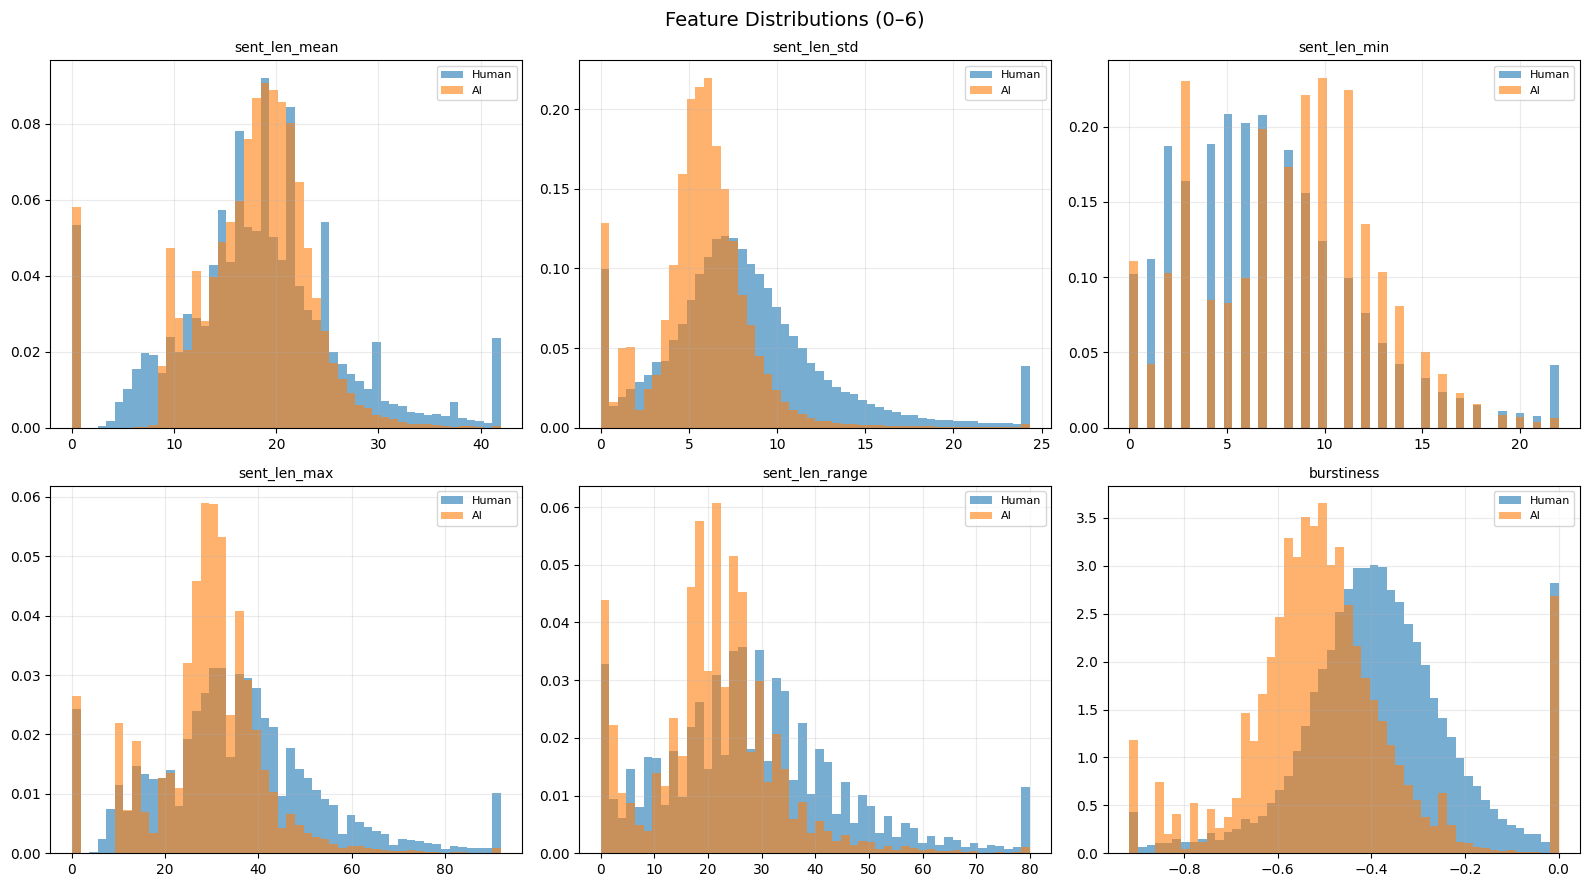

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

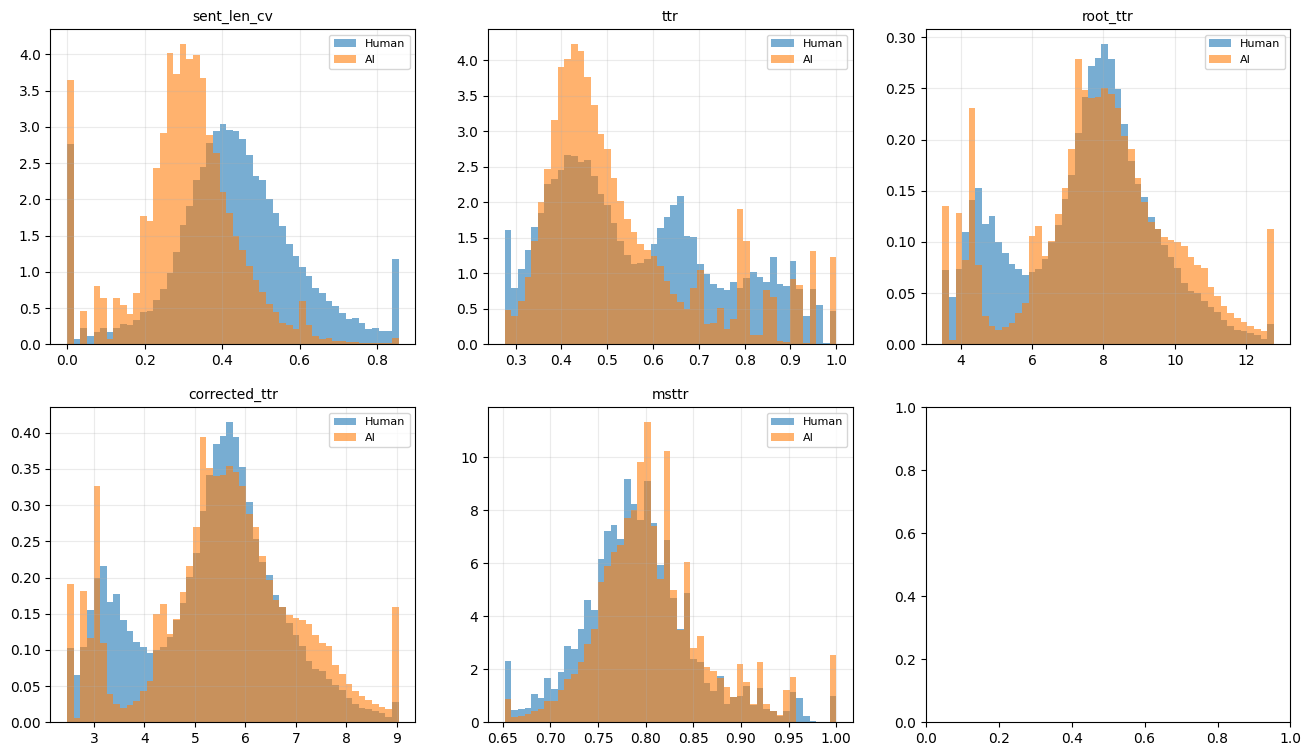

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Setup
# ----------------------------
labels = df["label"].reset_index(drop=True)

# auto-select numeric features
key = final_features.select_dtypes(include=[np.number]).columns.tolist()

print(f"Total features: {len(key)}")

save_dir = "feature_plots"
os.makedirs(save_dir, exist_ok=True)

batch_size = 6


# ----------------------------
# Loop over batches
# ----------------------------
for i in range(0, len(key), batch_size):
    subset = key[i:i+batch_size]

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for ax, feat in zip(axes, subset):

        # ----------------------------
        # Safe column check
        # ----------------------------
        if feat not in final_features.columns:
            ax.set_title(f"{feat}\nNOT FOUND")
            ax.axis("off")
            continue

        human = final_features.loc[labels == 0.0, feat].dropna()
        ai    = final_features.loc[labels == 1.0, feat].dropna()

        # ----------------------------
        # Empty check
        # ----------------------------
        if len(human) == 0 or len(ai) == 0:
            ax.set_title(f"{feat}\nEMPTY")
            ax.axis("off")
            continue
        human = final_features.loc[labels == 0.0, feat]
        ai    = final_features.loc[labels == 1.0, feat]
        
        # ensure 1D
        human = human.squeeze()
        ai = ai.squeeze()
        
        # drop NaNs
        human = human.dropna()
        ai = ai.dropna()
        
        if len(human) == 0 or len(ai) == 0:
            ax.set_title(f"{feat}\nEMPTY")
            ax.axis("off")
            continue
        
        combined = pd.concat([human, ai])
        
        # constant check (safe now)
        if combined.nunique() <= 1:
            ax.set_title(f"{feat}\nCONSTANT")
            ax.axis("off")
            continue      

        # ----------------------------
        # CONSTANT CHECK (FIXED)
        # ----------------------------
        if len(pd.unique(combined)) <= 1:
            ax.set_title(f"{feat}\nCONSTANT")
            ax.axis("off")
            continue

        # ----------------------------
        # Outlier clipping
        # ----------------------------
        lower, upper = np.percentile(combined, [1, 99])
        human_clip = human.clip(lower, upper)
        ai_clip    = ai.clip(lower, upper)

        combined_clip = pd.concat([human_clip, ai_clip])

        bins = np.histogram_bin_edges(combined_clip, bins=50)

        # ----------------------------
        # Batch plot
        # ----------------------------
        ax.hist(human_clip, bins=bins, alpha=0.6, density=True, label="Human")
        ax.hist(ai_clip, bins=bins, alpha=0.6, density=True, label="AI")

        ax.set_title(feat, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)

        # ----------------------------
        # SAVE INDIVIDUAL PLOT
        # ----------------------------
        plt.figure(figsize=(5, 4))
        plt.hist(human_clip, bins=bins, alpha=0.6, density=True, label="Human")
        plt.hist(ai_clip, bins=bins, alpha=0.6, density=True, label="AI")

        plt.title(feat)
        plt.legend()
        plt.grid(alpha=0.3)

        safe_name = feat.replace("/", "_").replace(" ", "_")
        plt.savefig(f"{save_dir}/{safe_name}.png", dpi=150, bbox_inches="tight")
        plt.close()

    # ----------------------------
    # Turn off unused axes
    # ----------------------------
    for ax in axes[len(subset):]:
        ax.axis("off")

    plt.suptitle(f"Feature Distributions ({i}–{i+len(subset)})", fontsize=14)
    plt.tight_layout()
    plt.show()

In [3]:
import pandas as pd

# Load pickle file
df = pd.read_pickle("features_partial.pkl",compression="xz")

# Get columns starting with 'l'
l_columns = [col for col in df.columns if col.startswith('l')]

print("Columns starting with 'l':", l_columns)

# View those columns
print(df[l_columns].head())

Columns starting with 'l': ['long_phrase_redundancy', 'local_entropy_mean', 'local_entropy_std', 'local_entropy_min', 'local_entropy_max', 'list_rate', 'list_style_consistency', 'line_len_mean', 'line_len_std', 'line_uniformity']
   long_phrase_redundancy  local_entropy_mean  local_entropy_std  \
0                0.005050            3.120743           0.153621   
1                0.002392            3.217226           0.071286   
2                0.006849            3.220449           0.080237   
3                0.003380            3.253011           0.080884   
4                0.004610            3.204357           0.098406   

   local_entropy_min  local_entropy_max  list_rate  list_style_consistency  \
0           2.820816           3.354988        0.0                     0.0   
1           3.042845           3.401197        0.0                     0.0   
2           2.994328           3.354988        0.0                     0.0   
3           3.060287           3.401197        0.

In [8]:
l_columns = [col for col in df.columns] 

In [4]:
features = pd.read_pickle("features_full.pkl",compression="xz")
original = pd.read_csv("final_dataset.csv")

df = features.merge(original[['text', 'label']], on='text', how='left')

KeyError: 'text'

In [9]:
print(l_columns)

['sent_len_mean', 'sent_len_std', 'sent_len_min', 'sent_len_max', 'sent_len_range', 'burstiness', 'sent_len_cv', 'ttr', 'root_ttr', 'corrected_ttr', 'msttr', 'hapax_ratio', 'rare_ratio', 'top10_coverage', 'top1_word_freq', 'vocab_size', 'discourse_marker_rate', 'safe_vocab_rate', 'importance_word_rate', 'template_phrase_count', 'it_is_rate', 'this_is_rate', 'there_is_rate', 'sentence_start_marker_rate', 'synonym_cycle_score', 'safe_vocab_diversity', 'intro_template_flag', 'ending_template_flag', 'stacked_marker_count', 'marker_burstiness', 'word_entropy', 'normalized_word_entropy', 'bigram_entropy', 'normalized_bigram_entropy', 'trigram_entropy', 'normalized_trigram_entropy', 'bigram_reuse_rate', 'trigram_reuse_rate', 'fourgram_reuse_rate', 'word_redundancy', 'long_phrase_redundancy', 'local_entropy_mean', 'local_entropy_std', 'local_entropy_min', 'local_entropy_max', 'entropy_variation_ratio', 'zipf_deviation', 'zipf_slope', 'zipf_r_squared', 'zipf_residual_std', 'zipf_residual_mean_a

In [10]:
print(len(features), len(original))

464943 471874


In [23]:
pre = pd.read_pickle("final_training_dataset.pkl")
l_columns = [col for col in pre.columns] 
print(l_columns)

['sent_len_mean', 'sent_len_std', 'sent_len_min', 'sent_len_max', 'sent_len_range', 'burstiness', 'sent_len_cv', 'ttr', 'root_ttr', 'corrected_ttr', 'msttr', 'hapax_ratio', 'rare_ratio', 'top10_coverage', 'top1_word_freq', 'vocab_size', 'discourse_marker_rate', 'safe_vocab_rate', 'importance_word_rate', 'template_phrase_count', 'it_is_rate', 'this_is_rate', 'there_is_rate', 'sentence_start_marker_rate', 'synonym_cycle_score', 'safe_vocab_diversity', 'intro_template_flag', 'ending_template_flag', 'stacked_marker_count', 'marker_burstiness', 'word_entropy', 'normalized_word_entropy', 'bigram_entropy', 'normalized_bigram_entropy', 'trigram_entropy', 'normalized_trigram_entropy', 'bigram_reuse_rate', 'trigram_reuse_rate', 'fourgram_reuse_rate', 'word_redundancy', 'long_phrase_redundancy', 'local_entropy_mean', 'local_entropy_std', 'local_entropy_min', 'local_entropy_max', 'entropy_variation_ratio', 'zipf_deviation', 'zipf_slope', 'zipf_r_squared', 'zipf_residual_std', 'zipf_residual_mean_a

In [21]:
print(len(features), len(pre))

464943 464943


In [24]:
import pandas as pd



# sanity check
assert len(features) == len(pre), "Mismatch!"

# attach labels
features['label'] = pre['label'].values


# save final dataset
features.to_pickle("final_final_training_dataset.pkl")

print("✅ Dataset ready for training")

✅ Dataset ready for training
